### Analyzing the results of spatial joining everything together

In ArcGIS I assigned an urban/rural locale type to each restaurant and calculated the distance to the nearest restaurant for every census tract. This notebook analyzes the data and aggregates the restaurants by locale type for making charts.  

In [1]:
import pandas as pd

In [ ]:
# load chinese restaurants by locale type

restaurants = pd.read_csv('table_us_rest_by_locale.csv') # note to self: i deleted this csv, too similar to restaurant_count_per_tract.csv
print(restaurants.shape)
restaurants.head()

(57536, 20)


,TARGET_FID,fsq_place_id,name,locality,region,date_created,date_refreshed,date_closed,still_open,LOCALE,STATEFP,LOC_NAME,latitude,longitude,address,postcode,admin_region,post_town,po_box,country
0,1,4c8c4e92cf3ea1434a7af451,Lee's Chinese,Fort Bragg,CA,9/12/2010,8/22/2025,NaN,1,33.0,6.0,Remote Town,39.444009,-123.804738,154 E Redwood Ave,95437.0,NaN,NaN,NaN,US
1,2,4f442d5819836ed00192b620,China Express,Fort Bragg,CA,2/21/2012,7/3/2025,NaN,1,33.0,6.0,Remote Town,39.433506,-123.805474,660 S Main St,95437.0,NaN,NaN,NaN,US
2,3,a194a71384e241d278559b60,Hill House Restaurant,Mendocino,CA,5/21/2012,5/21/2012,NaN,1,42.0,6.0,Distant Rural,39.310533,-123.798360,10701 Palette Dr,95460.0,NaN,NaN,NaN,US
3,4,5dffd431f4a5f60008cfa1ce,Panda Express,Ukiah,CA,12/22/2019,7/3/2025,NaN,1,33.0,6.0,Remote Town,39.130484,-123.198543,1236 Airport Park Blvd,95482.0,NaN,NaN,NaN,US
4,5,4f32482419836c91c7c8471b,New Dragon,Ukiah,CA,2/8/2012,7/3/2025,NaN,1,33.0,6.0,Remote Town,39.140123,-123.205708,765 S State St,95482.0,NaN,NaN,NaN,US


In [3]:
# restaurants that are probably still open: 'date_closed' is null

still_open = restaurants[restaurants['date_closed'].isna()]
print(f'open restaurants: {len(still_open)}')

open restaurants: 45077


In [9]:
# restaurants that are probably closed: 'date_closed' is not null

closed_restaurants = restaurants[restaurants['date_closed'].notna()]
print(f'closed restaurants: {len(closed_restaurants)}')

closed restaurants: 12459


In [ ]:
# count restaurants by locale type
restaurants_by_loc = restaurants['LOC_NAME'].value_counts()
print("Restaurants by locale type:")
restaurants_by_loc


In [16]:
# count restaurants by locale type

restaurants_by_loc = restaurants['LOC_NAME'].value_counts()
print("Restaurants by locale type:")
restaurants_by_loc

Restaurants by locale type:


LOC_NAME
Large Suburban      20133
Large City          15629
Small City           5337
Midsize City         4855
Distant Town         2763
Midsize Suburban     1572
Fringe Town          1565
Remote Town          1413
Distant Rural        1297
Fringe Rural         1281
Small Suburban        931
Remote Rural          702
Name: count, dtype: int64

In [14]:
# load census population data by locale type

pop_df = pd.read_csv('table_population.csv')
print(pop_df.shape)

(84400, 15)


In [17]:
# count chinese people by locale type

chinese_by_loc = pop_df.groupby('LOC_NAME')['chinese'].sum()
print("Chinese people by locale type:")
chinese_by_loc


Chinese people by locale type:


LOC_NAME
Distant Rural         39045
Distant Town          17445
Fringe Rural         303442
Fringe Town           15144
Large City          1519166
Large Suburban      1560510
Midsize City         332138
Midsize Suburban      56355
Remote Rural           8046
Remote Town           10723
Small City           295340
Small Suburban        22636
Name: chinese, dtype: int64

In [25]:
# average percentage of chinese people by locale type
avg_ch_pct_by_loc = pop_df.groupby('LOC_NAME')['ch_pct'].mean()
print("Average percentage of Chinese people by locale type:")
avg_ch_pct_by_loc


Average percentage of Chinese people by locale type:


LOC_NAME
Distant Rural       0.098958
Distant Town        0.257361
Fringe Rural        0.442299
Fringe Town         0.294118
Large City          2.496643
Large Suburban      1.461826
Midsize City        1.333804
Midsize Suburban    0.575525
Remote Rural        0.060636
Remote Town         0.264207
Small City          1.198427
Small Suburban      0.514851
Name: ch_pct, dtype: float64

In [ ]:
# chinese restaurants per capita (per 100 chinese people) for each locale type
chinese_restaurants_per_capita = restaurants_by_loc / chinese_by_loc * 100
print("Chinese restaurants per capita by locale type:")
chinese_restaurants_per_capita

Chinese restaurants per capita by locale type:


LOC_NAME
Distant Rural        3.321808
Distant Town        15.838349
Fringe Rural         0.422156
Fringe Town         10.334126
Large City           1.028788
Large Suburban       1.290155
Midsize City         1.461742
Midsize Suburban     2.789460
Remote Rural         8.724832
Remote Town         13.177282
Small City           1.807070
Small Suburban       4.112917
dtype: float64

In [46]:
# distance to the nearest chinese restaurant by locale type
avg_distance = pop_df.groupby('LOC_NAME')['NEAR_DIST'].mean()
print("Average distance to nearest Chinese restaurant by locale type:")
avg_distance

Average distance to nearest Chinese restaurant by locale type:


LOC_NAME
Distant Rural       12.930588
Distant Town         2.213468
Fringe Rural         5.191519
Fringe Town          2.304390
Large City           0.920667
Large Suburban       1.463796
Midsize City         1.229000
Midsize Suburban     2.042448
Remote Rural        27.930945
Remote Town          3.368195
Small City           1.338789
Small Suburban       2.236139
Name: NEAR_DIST, dtype: float64

In [58]:
# map locale codes to locale names
locale_mapping = pop_df[['LOC_NAME', 'LOCALE']].drop_duplicates().set_index('LOC_NAME')
locale_mapping.shape
locale_mapping

,LOCALE
LOC_NAME,
Midsize City,12.0
Large Suburban,21.0
Distant Town,32.0
Small City,13.0
Fringe Town,31.0
Distant Rural,42.0
Remote Rural,43.0
Fringe Rural,41.0
Remote Town,33.0


In [ ]:
# combine all the locale-based data
locales_df = pd.DataFrame({
    'locale_code': locale_mapping['LOCALE'],
    'restaurants': restaurants_by_loc,
    'chinese': chinese_by_loc,
    'avg_ch_pct': avg_ch_pct_by_loc,
    'avg_distance': avg_distance,
    'restaurants_per_100chppl': chinese_restaurants_per_capita
})

print("Combined locale-based data:")
locales_df


Combined locale-based data:


,locale_code,restaurants,chinese,avg_ch_pct,avg_distance,restaurants_per_100chppl
LOC_NAME,,,,,,
Distant Rural,42.0,1297.0,39045.0,0.098958,12.930588,3.321808
Distant Town,32.0,2763.0,17445.0,0.257361,2.213468,15.838349
Fringe Rural,41.0,1281.0,303442.0,0.442299,5.191519,0.422156
Fringe Town,31.0,1565.0,15144.0,0.294118,2.304390,10.334126
Large City,11.0,15629.0,1519166.0,2.496643,0.920667,1.028788
Large Suburban,21.0,20133.0,1560510.0,1.461826,1.463796,1.290155
Midsize City,12.0,4855.0,332138.0,1.333804,1.229000,1.461742
Midsize Suburban,22.0,1572.0,56355.0,0.575525,2.042448,2.789460
Remote Rural,43.0,702.0,8046.0,0.060636,27.930945,8.724832


In [69]:
# remove mystery NAN row
locales_df = locales_df.dropna()
locales_df.shape


(12, 6)

In [70]:
# remove decimal places from locale_codes
locales_df['locale_code'] = locales_df['locale_code'].astype(int)
locales_df

# sort by locale_code
locales_df = locales_df.sort_values('locale_code')
locales_df


/var/folders/hh/gv6hw42j5x72r3w36vz87jk00000gn/T/ipykernel_56291/3762359062.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locales_df['locale_code'] = locales_df['locale_code'].astype(int)


,locale_code,restaurants,chinese,avg_ch_pct,avg_distance,restaurants_per_100chppl
LOC_NAME,,,,,,
Large City,11,15629.0,1519166.0,2.496643,0.920667,1.028788
Midsize City,12,4855.0,332138.0,1.333804,1.229000,1.461742
Small City,13,5337.0,295340.0,1.198427,1.338789,1.807070
Large Suburban,21,20133.0,1560510.0,1.461826,1.463796,1.290155
Midsize Suburban,22,1572.0,56355.0,0.575525,2.042448,2.789460
Small Suburban,23,931.0,22636.0,0.514851,2.236139,4.112917
Fringe Town,31,1565.0,15144.0,0.294118,2.304390,10.334126
Distant Town,32,2763.0,17445.0,0.257361,2.213468,15.838349
Remote Town,33,1413.0,10723.0,0.264207,3.368195,13.177282


In [67]:
# export as csv for charting
locales_df.to_csv('locales_df.csv', index=True)

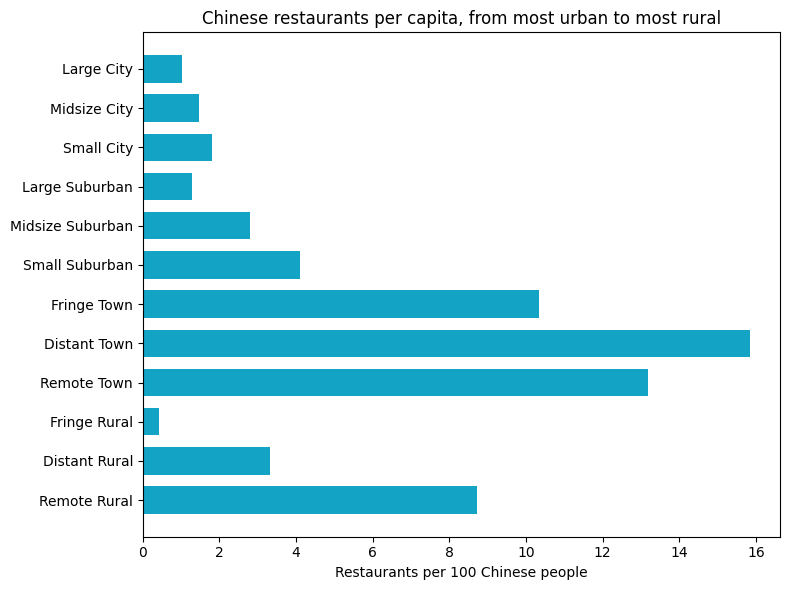

In [76]:
import matplotlib.pyplot as plt

# Sort by locale_code descending (most rural first)
plot_df = locales_df.sort_values('locale_code', ascending=False)

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 6))

# Get values for plotting
y_positions = range(len(plot_df))
y_labels = plot_df.index.tolist()
x_values = plot_df['restaurants_per_100chppl'].values

# Create horizontal bars
bars = ax.barh(y_positions, x_values, color='#13a3c4', height=0.7)

# Set y-axis labels and positions
ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels)

# Labels and title
ax.set_xlabel('Restaurants per 100 Chinese people')
ax.set_title('Chinese restaurants per capita, from most urban to most rural')

# Set white background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Adjust layout
plt.tight_layout()
plt.show()
